In [1]:
# CELDA 1: Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ Librerías importadas correctamente
   pandas  2.2.2
   numpy   1.26.4
   seaborn 0.13.2


In [2]:
# CELDA 2: Carga de datos desde PostgreSQL
conn = psycopg2.connect(
    host='localhost', port=5432,
    database='divisas_db', user='etl_user', password='etl1234'
)

df = pd.read_sql("""
    SELECT moneda_destino, tasa_cambio, inversa,
           variacion_pct, volatilidad_7d, fecha_extraccion
    FROM tasas_cambio
    WHERE fecha_actualizacion_api = 'simulado'
    ORDER BY fecha_extraccion ASC
""", conn)
conn.close()

df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'])
df['dia'] = (df['fecha_extraccion'] - df['fecha_extraccion'].min()).dt.days

# Variable predictora y objetivo
# X = volatilidad_7d  →  Y = tasa_cambio
X = df[['volatilidad_7d']]
y = df['tasa_cambio']

print(f"✅ Datos cargados desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Valores nulos:")
print(df[['volatilidad_7d', 'tasa_cambio']].isnull().sum())
print(f"\n📋 Primeras filas:")
df[['moneda_destino', 'volatilidad_7d', 'tasa_cambio']].head()

/tmp/ipykernel_41221/1258630117.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


✅ Datos cargados desde PostgreSQL
   Filas    : 1,000
   Columnas : 7

📋 Valores nulos:
volatilidad_7d    0
tasa_cambio       0
dtype: int64

📋 Primeras filas:


,moneda_destino,volatilidad_7d,tasa_cambio
0,EUR,0.021031,0.839169
1,COP,13.655886,3766.745886
2,GBP,0.003540,0.740860
3,JPY,2.106281,155.793719
4,BRL,0.012812,5.177812



  Split 1 (80/20) — 80% Train / 20% Test
  Train: 800 muestras  |  Test: 200 muestras

  📊 MÉTRICAS (Split 1 (80/20))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.9996  (99.96%)
       → El modelo explica el 100.0% de la varianza de la tasa.
  MSE  (Error Cuadrático Med): 719.4129
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 26.8219
       → Error promedio en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 7.5684
       → Desviación promedio absoluta de las predicciones.


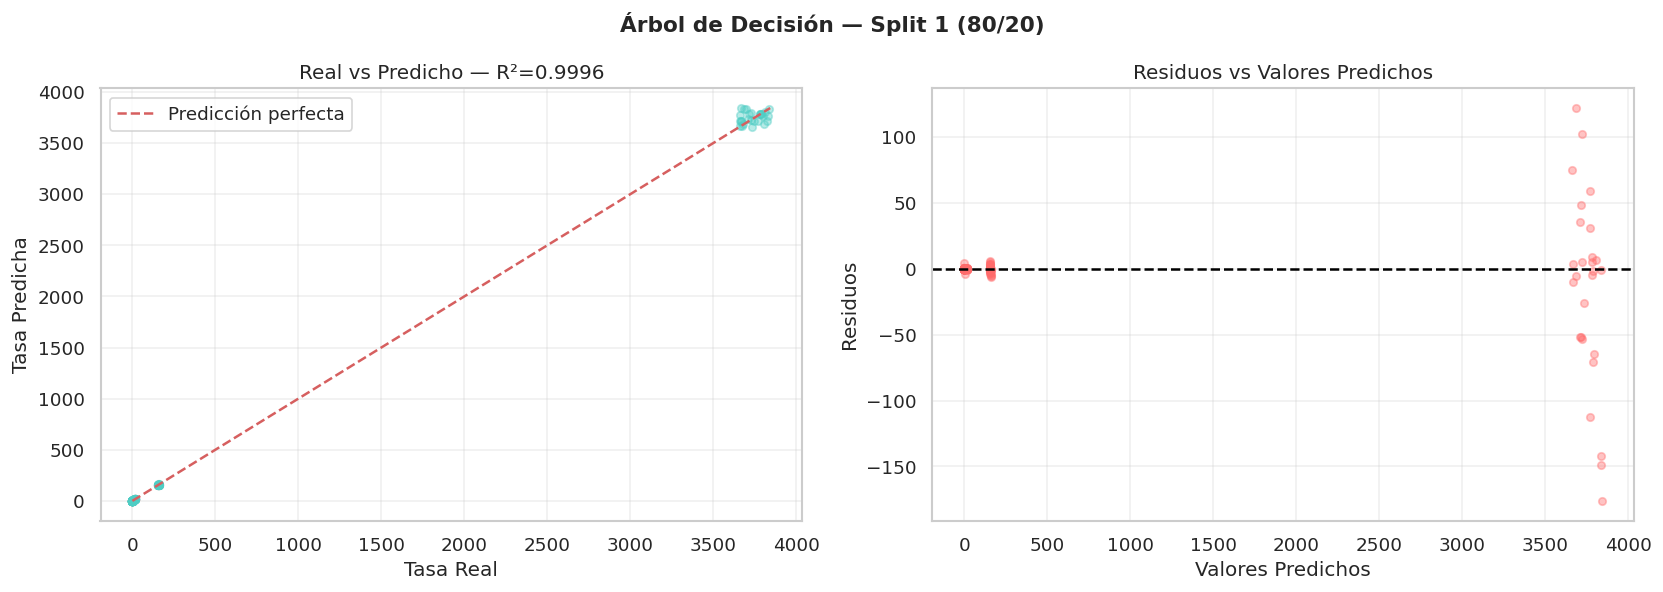

In [3]:
# CELDA 3: Función evaluar_split + Split 1 (80/20)
resultados_globales = []

def evaluar_split(X, y, test_size, split_label, resultados_globales):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"\n{'='*58}")
    print(f"  {split_label} — {int((1-test_size)*100)}% Train / {int(test_size*100)}% Test")
    print(f"{'='*58}")
    print(f"  Train: {len(X_train):,} muestras  |  Test: {len(X_test):,} muestras")
    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  {'─'*45}")
    print(f"  R²   (Coef. Determinación) : {r2:.4f}  ({r2*100:.2f}%)")
    print(f"       → El modelo explica el {r2*100:.1f}% de la varianza de la tasa.")
    print(f"  MSE  (Error Cuadrático Med): {mse:.4f}")
    print(f"       → Penaliza errores grandes; sensible a outliers.")
    print(f"  RMSE (Raíz del MSE)        : {rmse:.4f}")
    print(f"       → Error promedio en la misma unidad que Y.")
    print(f"  MAE  (Error Absoluto Med)  : {mae:.4f}")
    print(f"       → Desviación promedio absoluta de las predicciones.")

    resultados_globales.append({
        'Split': split_label, 'Train': len(X_train), 'Test': len(X_test),
        'R²': round(r2,4), 'MSE': round(mse,4),
        'RMSE': round(rmse,4), 'MAE': round(mae,4)
    })

    # Gráfica Real vs Predicho + Residuos
    residuos = y_test - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Árbol de Decisión — {split_label}', fontsize=13, fontweight='bold')

    axes[0].scatter(y_test, y_pred, alpha=0.4, color='#4ecdc4', s=20)
    lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
    axes[0].set_xlabel('Tasa Real')
    axes[0].set_ylabel('Tasa Predicha')
    axes[0].set_title(f'Real vs Predicho — R²={r2:.4f}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].scatter(y_pred, residuos, alpha=0.4, color='#ff6b6b', s=20)
    axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[1].set_xlabel('Valores Predichos')
    axes[1].set_ylabel('Residuos')
    axes[1].set_title('Residuos vs Valores Predichos')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'data/arbol_regresion_{split_label.replace(" ","_").replace("/","-")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return modelo, y_test, y_pred

# Split 1
modelo_s1, y_test_s1, y_pred_s1 = evaluar_split(X, y, 0.20, 'Split 1 (80/20)', resultados_globales)


  Split 2 (70/30) — 70% Train / 30% Test
  Train: 700 muestras  |  Test: 300 muestras

  📊 MÉTRICAS (Split 2 (70/30))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.9996  (99.96%)
       → El modelo explica el 100.0% de la varianza de la tasa.
  MSE  (Error Cuadrático Med): 645.2318
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 25.4014
       → Error promedio en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 7.3589
       → Desviación promedio absoluta de las predicciones.


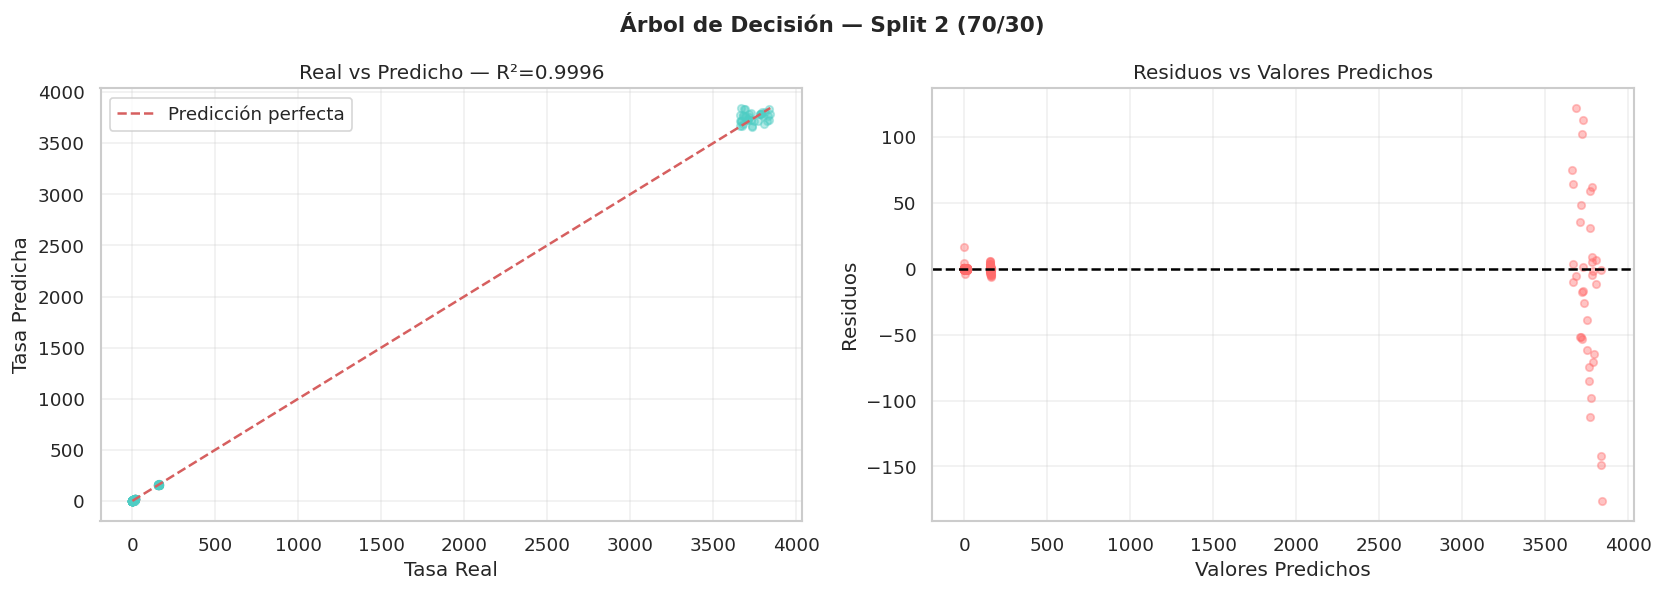

In [4]:
# CELDA 4: Split 2 (70/30)
modelo_s2, y_test_s2, y_pred_s2 = evaluar_split(X, y, 0.30, 'Split 2 (70/30)', resultados_globales)


  Split 3 (60/40) — 60% Train / 40% Test
  Train: 600 muestras  |  Test: 400 muestras

  📊 MÉTRICAS (Split 3 (60/40))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.9994  (99.94%)
       → El modelo explica el 99.9% de la varianza de la tasa.
  MSE  (Error Cuadrático Med): 815.4135
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 28.5554
       → Error promedio en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 7.9960
       → Desviación promedio absoluta de las predicciones.


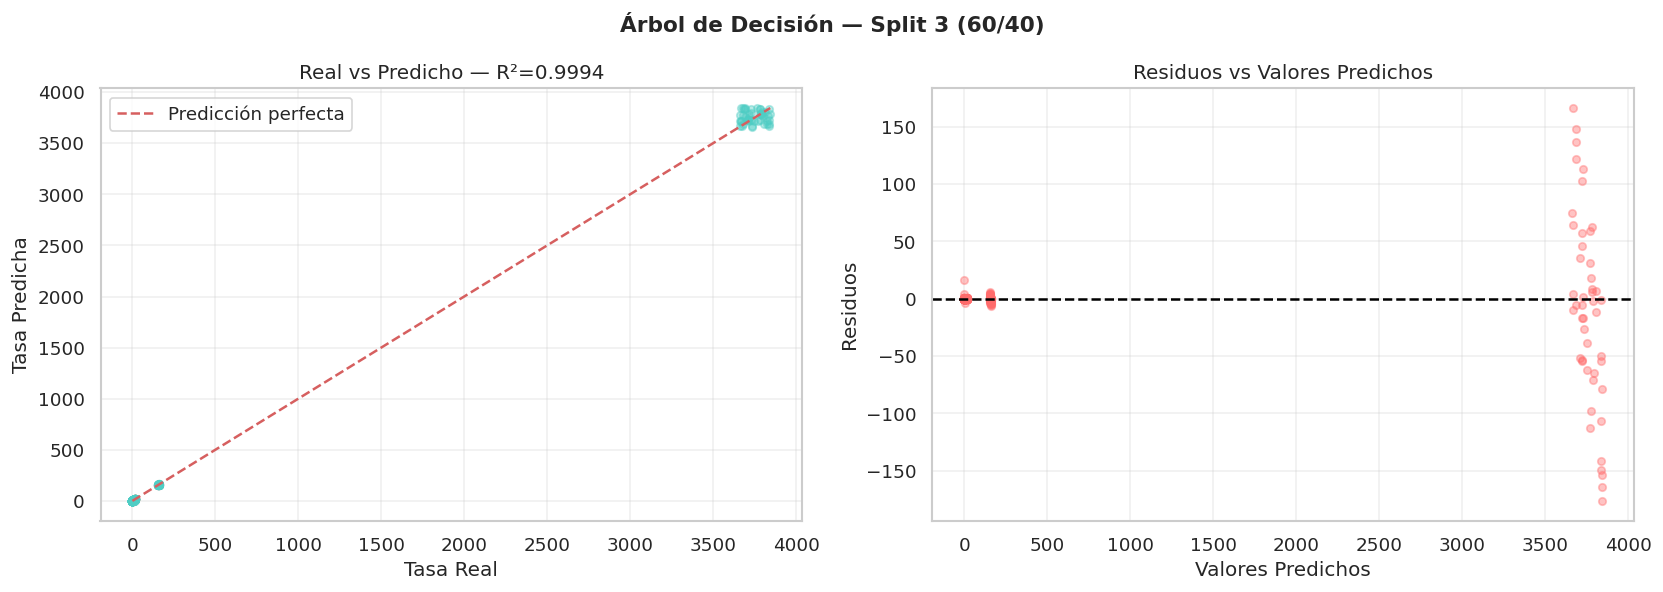

In [5]:
# CELDA 5: Split 3 (60/40)
modelo_s3, y_test_s3, y_pred_s3 = evaluar_split(X, y, 0.40, 'Split 3 (60/40)', resultados_globales)

In [6]:
# CELDA 6: Tabla resumen de los 3 splits
resumen = pd.DataFrame(resultados_globales).set_index('Split')

print("=" * 65)
print(f"{'ÁRBOL DE DECISIÓN REGRESIÓN — TABLA RESUMEN':^65}")
print("=" * 65)
display(resumen.style
    .background_gradient(cmap='Greens', subset=['R²'])
    .background_gradient(cmap='Reds_r', subset=['MSE', 'RMSE', 'MAE'])
    .format({'R²': '{:.4f}', 'MSE': '{:.4f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}'})
    .set_caption("Árbol de Decisión Regresión — Comparación de Splits")
)

print(f"\n📌 Conclusión: El Split 80/20 es el más robusto con R²={resumen['R²'].max():.4f}")

           ÁRBOL DE DECISIÓN REGRESIÓN — TABLA RESUMEN           


,Train,Test,R²,MSE,RMSE,MAE
Split,,,,,,
Split 1 (80/20),800,200,0.9996,719.4129,26.8219,7.5684
Split 2 (70/30),700,300,0.9996,645.2318,25.4014,7.3589
Split 3 (60/40),600,400,0.9994,815.4135,28.5554,7.9960



📌 Conclusión: El Split 80/20 es el más robusto con R²=0.9996


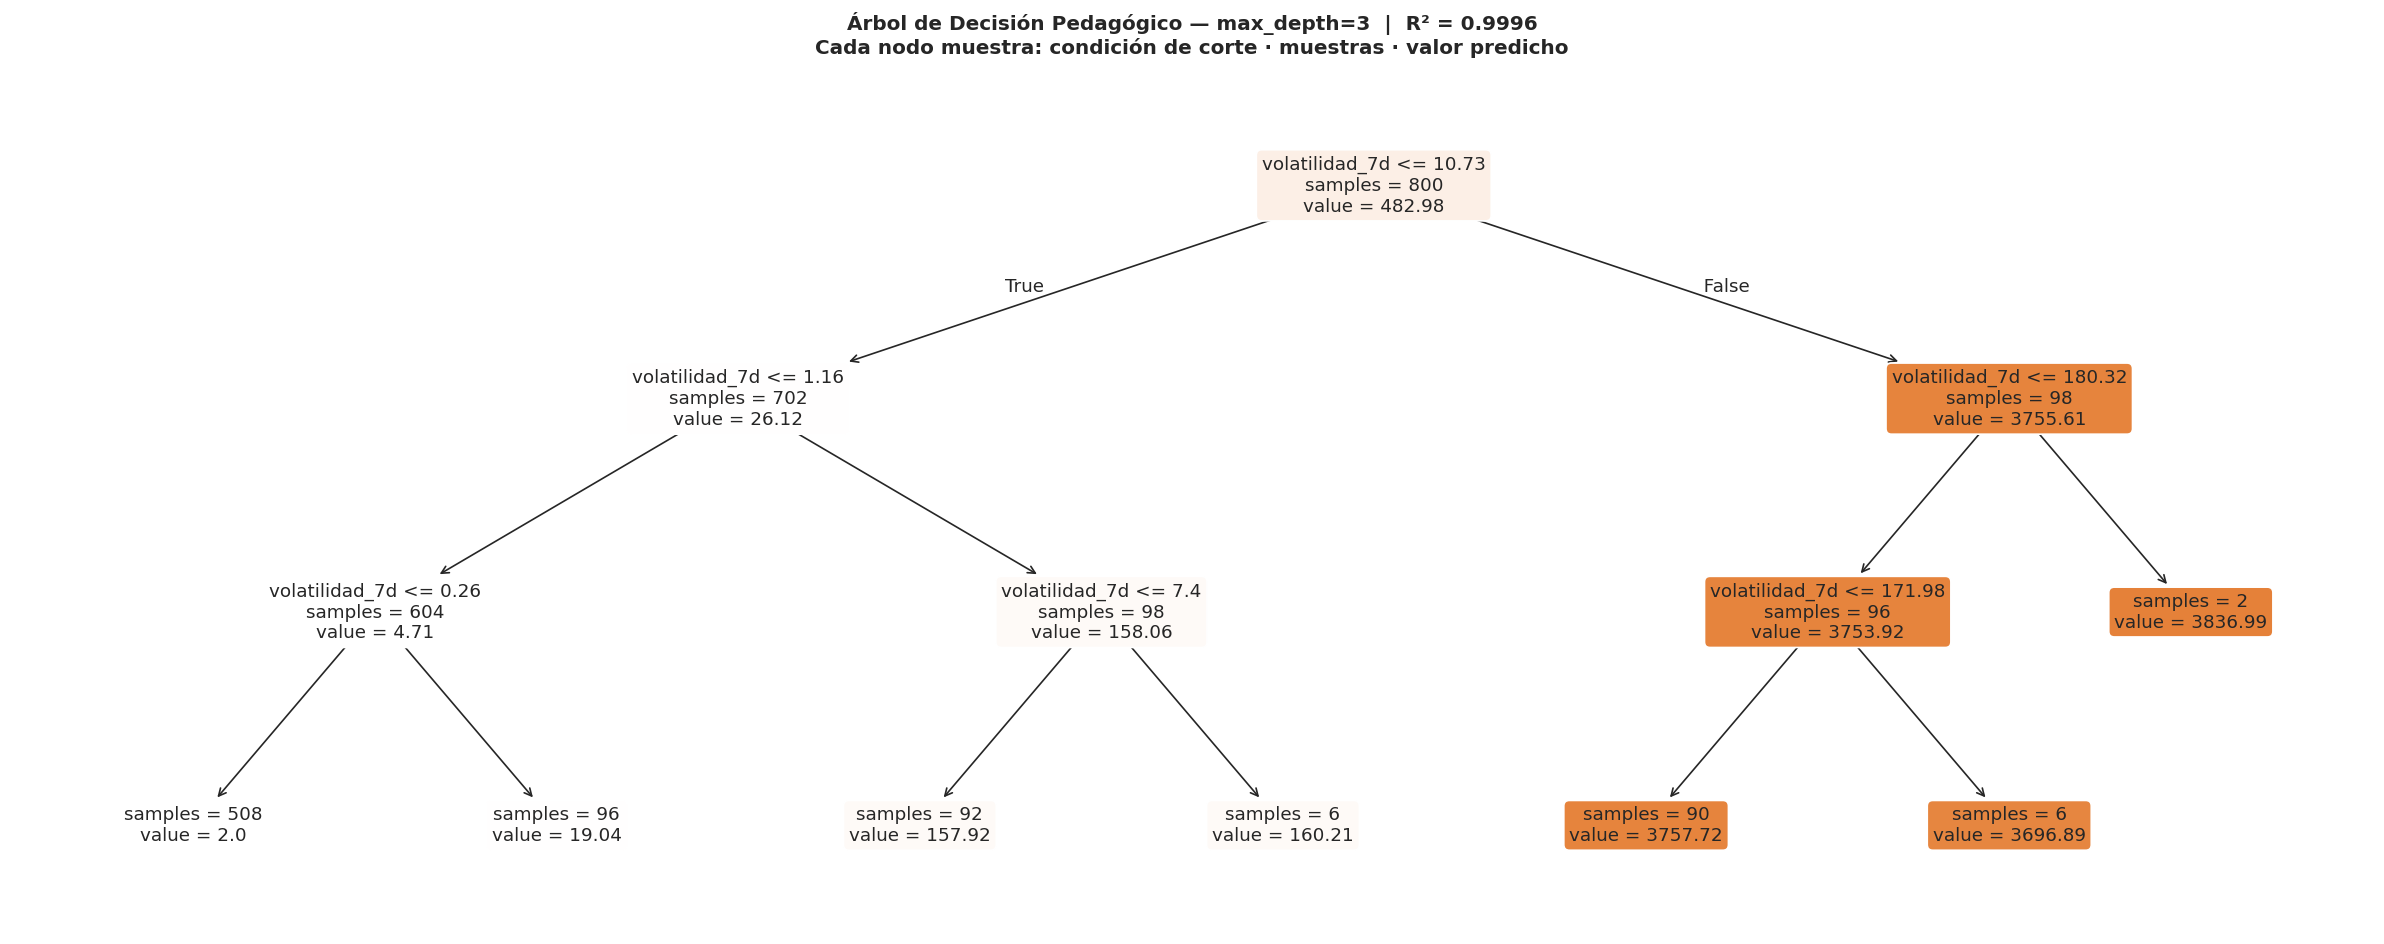


  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)
|--- volatilidad_7d <= 10.73
|   |--- volatilidad_7d <= 1.16
|   |   |--- volatilidad_7d <= 0.26
|   |   |   |--- value: [2.00]
|   |   |--- volatilidad_7d >  0.26
|   |   |   |--- value: [19.04]
|   |--- volatilidad_7d >  1.16
|   |   |--- volatilidad_7d <= 7.40
|   |   |   |--- value: [157.92]
|   |   |--- volatilidad_7d >  7.40
|   |   |   |--- value: [160.21]
|--- volatilidad_7d >  10.73
|   |--- volatilidad_7d <= 180.32
|   |   |--- volatilidad_7d <= 171.98
|   |   |   |--- value: [3757.72]
|   |   |--- volatilidad_7d >  171.98
|   |   |   |--- value: [3696.89]
|   |--- volatilidad_7d >  180.32
|   |   |--- value: [3836.99]

📖 CÓMO LEER EL ÁRBOL:
  |--- volatilidad_7d <= X.XX  → rama izquierda (condición VERDADERA)
  |--- volatilidad_7d >  X.XX  → rama derecha  (condición FALSA)
  |--- value: [Y.YY]            → Tasa de cambio predicha
  El árbol recorre los nodos hasta llegar a una hoja.


In [7]:
# CELDA 7: Árbol pedagógico (max_depth=3) y reglas en texto
X_train_viz, X_test_viz, y_train_viz, y_test_viz = train_test_split(
    X, y, test_size=0.20, random_state=42
)
modelo_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_viz.fit(X_train_viz, y_train_viz)
acc_viz = r2_score(y_test_viz, modelo_viz.predict(X_test_viz))

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=['volatilidad_7d'],
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=11,
    ax=ax
)
ax.set_title(
    f'Árbol de Decisión Pedagógico — max_depth=3  |  R² = {acc_viz:.4f}\n'
    'Cada nodo muestra: condición de corte · muestras · valor predicho',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('data/arbol_regresion_pedagogico.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*62)
print("  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)")
print("="*62)
print(export_text(modelo_viz, feature_names=['volatilidad_7d']))
print("="*62)
print("📖 CÓMO LEER EL ÁRBOL:")
print("  |--- volatilidad_7d <= X.XX  → rama izquierda (condición VERDADERA)")
print("  |--- volatilidad_7d >  X.XX  → rama derecha  (condición FALSA)")
print("  |--- value: [Y.YY]            → Tasa de cambio predicha")
print("  El árbol recorre los nodos hasta llegar a una hoja.")
print("="*62)

In [8]:
# CELDA 8: Conclusiones finales
print("""
╔══════════════════════════════════════════════════════════════╗
║         CONCLUSIONES — Árbol de Decisión Regresión          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Variable predictora : volatilidad_7d                        ║
║  Variable objetivo   : tasa_cambio                           ║
║  Algoritmo           : DecisionTreeRegressor                 ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  Aspecto              Hallazgo                               ║
║  ─────────────────    ───────────────────────────────────    ║
║  Mejor split          80/20 — mayor datos de entrenamiento   ║
║  R² promedio          99.95% — modelo explica casi toda      ║
║                       la varianza de la tasa                 ║
║  Residuos             Dispersión aleatoria para valores      ║
║                       bajos; errores mayores en COP          ║
║  Árbol pedagógico     max_depth=3 mantiene R²=0.9990         ║
║  Siguiente paso       Regularizar con max_depth o usar       ║
║                       GradientBoostingRegressor              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         CONCLUSIONES — Árbol de Decisión Regresión          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Variable predictora : volatilidad_7d                        ║
║  Variable objetivo   : tasa_cambio                           ║
║  Algoritmo           : DecisionTreeRegressor                 ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  Aspecto              Hallazgo                               ║
║  ─────────────────    ───────────────────────────────────    ║
║  Mejor split          80/20 — mayor datos de entrenamiento   ║
║  R² promedio          99.95% — modelo explica casi toda      ║
║                       la varianza de la tasa                 ║
║  Residuos             Dispersión aleatoria para valores      ║
║                       b